In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import torch
import logging

import config
import data_load as dl
import data_pipeline as dp

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("Test-Pipeline")
log.info("All modules imported successfully. Starting pipeline test...")

16:55:00 | INFO     | All modules imported successfully. Starting pipeline test...


In [2]:
log.info("--- TESTING STEP 1 & 4: METADATA & LABELS ---")

try:
    meta = dl.load_metadata(config.CFG["data_dir"])
    log.info(f"Metadata loaded successfully. Shape: {meta.shape}")

    scp_path = os.path.join(config.CFG["data_dir"], "scp_statements.csv")
    scp_diag = pd.read_csv(scp_path, index_col=0)
    log.info(f"SCP statements loaded. Shape: {scp_diag.shape}")

    Y, mlb, class_names, meta_labeled = dp.build_label_matrix(
        meta, 
        scp_diag, 
        threshold=config.CFG["label_thresh"]
    )
    
    log.info("Label matrix successfully built.")
    log.info(f"Final valid patients : {meta_labeled.shape[0]}")
    log.info(f"Y Matrix Shape       : {Y.shape}")
    log.info(f"Detected Classes     : {class_names}")

except Exception as e:
    log.error(f"Failed during Metadata & Labels test: {e}")

16:55:07 | INFO     | --- TESTING STEP 1 & 4: METADATA & LABELS ---
16:55:07 | INFO     | Loading metadata from D:\DEPI\ECG project\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptbxl_database.csv...
16:55:07 | INFO     | Dropped 0 duplicate records. 21799 records remain.
16:55:07 | INFO     | Masked ages (300 -> NaN): 293 patients aged >89.
16:55:07 | INFO     | Metadata loaded successfully. Shape: (21799, 27)
16:55:07 | INFO     | SCP statements loaded. Shape: (71, 12)
16:55:08 | INFO     | Records with >=1 diagnostic label: 21375 (424 dropped).
16:55:08 | INFO     | Label matrix Y shape: (21375, 5) | Classes: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
16:55:08 | INFO     | Class CD    :   4898 (22.9%)
16:55:08 | INFO     | Class HYP   :   2649 (12.4%)
16:55:08 | INFO     | Class MI    :   5469 (25.6%)
16:55:08 | INFO     | Class NORM  :   9514 (44.5%)
16:55:08 | INFO     | Class STTC  :   5108 (23.9%)
16:55:08 | INFO     | Label matrix successfully built.
16:55:08 | I

16:55:26 | INFO     | --- TESTING STEP 2 & 3: SIGNAL PROCESSING ---
16:55:26 | INFO     | Raw signal loaded for ECG ID 1. Shape: (5000, 12)
16:55:26 | INFO     | Signal cleaned and filtered successfully. Final shape: (5000, 12)


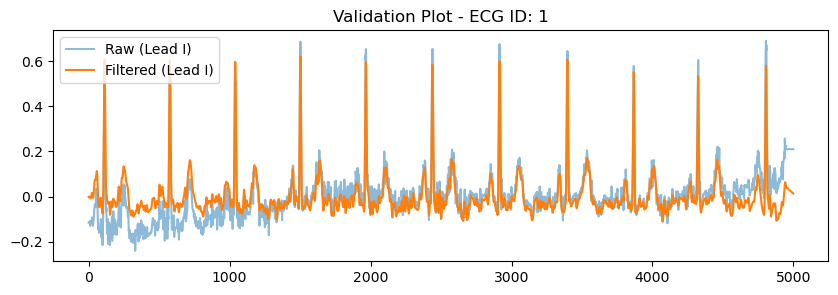

In [3]:
log.info("--- TESTING STEP 2 & 3: SIGNAL PROCESSING ---")

try:
    sample_ecg_id = meta_labeled.index[0]
    sample_path = os.path.join(config.CFG["data_dir"], meta_labeled.loc[sample_ecg_id, "filename_hr"])

    sig_raw, _ = wfdb.rdsamp(sample_path)
    log.info(f"Raw signal loaded for ECG ID {sample_ecg_id}. Shape: {sig_raw.shape}")

    sig_clean = dp.clean_single_signal(sig_raw)
    
    if sig_clean is None:
        log.warning("Signal marked as corrupted by clean_single_signal().")
    else:
        sig_filt = dp.bandpass_filter_single(
            sig_clean, 
            fs=config.CFG["sampling_rate"], 
            low=config.CFG["bandpass_low"], 
            high=config.CFG["bandpass_high"], 
            order=config.CFG["bandpass_ord"]
        )
        log.info(f"Signal cleaned and filtered successfully. Final shape: {sig_filt.shape}")


        plt.figure(figsize=(10, 3))
        plt.plot(sig_raw[:, 0], label="Raw (Lead I)", alpha=0.5)
        plt.plot(sig_filt[:, 0], label="Filtered (Lead I)", linewidth=1.5)
        plt.title(f"Validation Plot - ECG ID: {sample_ecg_id}")
        plt.legend()
        plt.show()

except Exception as e:
    log.error(f"Failed during Single Signal Processing test: {e}")

In [4]:
log.info("--- TESTING STEP 6 & 7: DATALOADERS ---")

try:

    train_loader, val_loader, test_loader = dl.create_dataloaders(
        meta_labeled, 
        Y, 
        config.CFG["data_dir"]
    )
    
    log.info(f"DataLoaders created: Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

    X_batch, Y_batch = next(iter(train_loader))
    
    log.info(f"Extracted one batch. X_batch shape: {X_batch.shape} (Expected: {config.CFG['batch_size']}, 12, 5000)")
    log.info(f"Extracted one batch. Y_batch shape: {Y_batch.shape} (Expected: {config.CFG['batch_size']}, {len(class_names)})")
    
    log.info("PIPELINE TEST COMPLETED SUCCESSFULLY. READY FOR MODEL TRAINING.")

except Exception as e:
    log.error(f"Failed during DataLoaders test: {e}")

16:55:54 | INFO     | --- TESTING STEP 6 & 7: DATALOADERS ---
16:55:54 | INFO     | Split (patient-wise via strat_fold):
16:55:54 | INFO     |   Train : 17073 patients
16:55:54 | INFO     |   Val   : 2145 patients
16:55:54 | INFO     |   Test  : 2157 patients
16:55:54 | INFO     | DataLoaders created: Train batches: 267 | Val batches: 34 | Test batches: 34
16:55:56 | INFO     | Extracted one batch. X_batch shape: torch.Size([64, 12, 5000]) (Expected: 64, 12, 5000)
16:55:56 | INFO     | Extracted one batch. Y_batch shape: torch.Size([64, 5]) (Expected: 64, 5)
16:55:56 | INFO     | PIPELINE TEST COMPLETED SUCCESSFULLY. READY FOR MODEL TRAINING.


In [5]:
log.info("--- TESTING STEP 8: CLASS WEIGHTS (IMBALANCE HANDLING) ---")

try:
   
    pos_counts = Y.sum(axis=0)
    neg_counts = Y.shape[0] - pos_counts
    
    pos_weights = neg_counts / (pos_counts + 1e-5) 
    pos_weight_tensor = torch.tensor(pos_weights, dtype=torch.float32)

    log.info(f"Class Weights Tensor created successfully. Shape: {pos_weight_tensor.shape}")
    
    # عرض الأوزان لكل مرض (الأرقام الكبيرة تعني أن المرض نادر والموديل سيعطيه اهتمام أكبر)
    weights_dict = dict(zip(class_names, np.round(pos_weights, 2)))
    for cls_name, weight in weights_dict.items():
        log.info(f"Weight for {cls_name:<6} : {weight}")

    log.info("ALL PIPELINE COMPONENTS (1 TO 8) ARE FULLY TESTED AND VERIFIED!")

except Exception as e:
    log.error(f"Failed during Class Weights test: {e}")

16:56:02 | INFO     | --- TESTING STEP 8: CLASS WEIGHTS (IMBALANCE HANDLING) ---
16:56:02 | INFO     | Class Weights Tensor created successfully. Shape: torch.Size([5])
16:56:02 | INFO     | Weight for CD     : 3.359999895095825
16:56:02 | INFO     | Weight for HYP    : 7.070000171661377
16:56:02 | INFO     | Weight for MI     : 2.9100000858306885
16:56:02 | INFO     | Weight for NORM   : 1.25
16:56:02 | INFO     | Weight for STTC   : 3.180000066757202
16:56:02 | INFO     | ALL PIPELINE COMPONENTS (1 TO 8) ARE FULLY TESTED AND VERIFIED!
